# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk pemrosesan teks awal (RegEx)
import re

# Mengatur visualisasi agar terlihat rapi dan konsisten
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Tentukan path file dataset
file_path = 'PRDECT-ID Dataset.csv'

# Memuat dataset menggunakan pandas
df = pd.read_csv(file_path)

# 1. Menampilkan 5 baris pertama untuk melihat struktur data awal
print("--- 5 Baris Pertama Dataset ---")
display(df.head())

# 2. Memeriksa informasi umum dataset (jumlah baris, kolom, dan tipe data)
print("\n--- Informasi Umum Dataset ---")
df.info()

# 3. Memeriksa keberadaan nilai kosong (missing values) sebagai pemenuhan syarat pembersihan nanti
print("\n--- Jumlah Nilai Kosong per Kolom ---")
print(df.isnull().sum())

--- 5 Baris Pertama Dataset ---


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy



--- Informasi Umum Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB

--- Jumlah Nilai Kosong per Kolom ---
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rati

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Distribusi Kelas Emosi ---
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


/tmp/ipykernel_2739/3252264640.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_column, order=df[target_column].value_counts().index, palette='viridis')


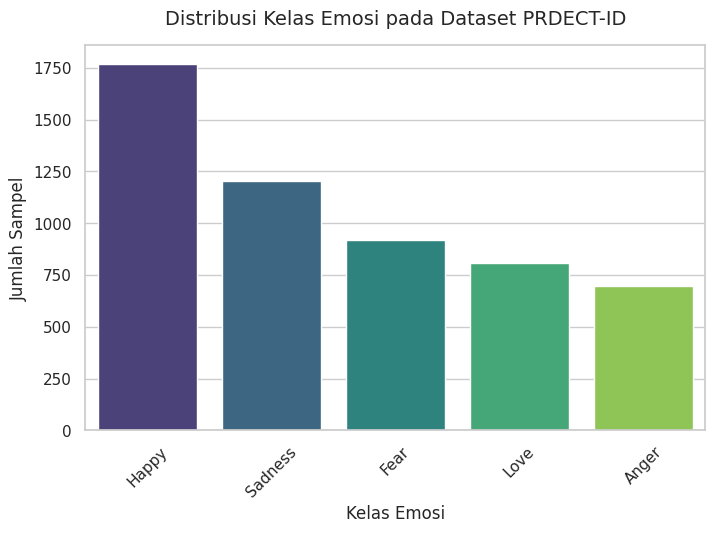


--- Statistik Deskriptif Panjang Teks (Jumlah Kata) ---
count    5400.000000
mean       16.095000
std        15.647181
min         1.000000
25%         7.000000
50%        12.000000
75%        20.000000
max       184.000000
Name: word_count, dtype: float64


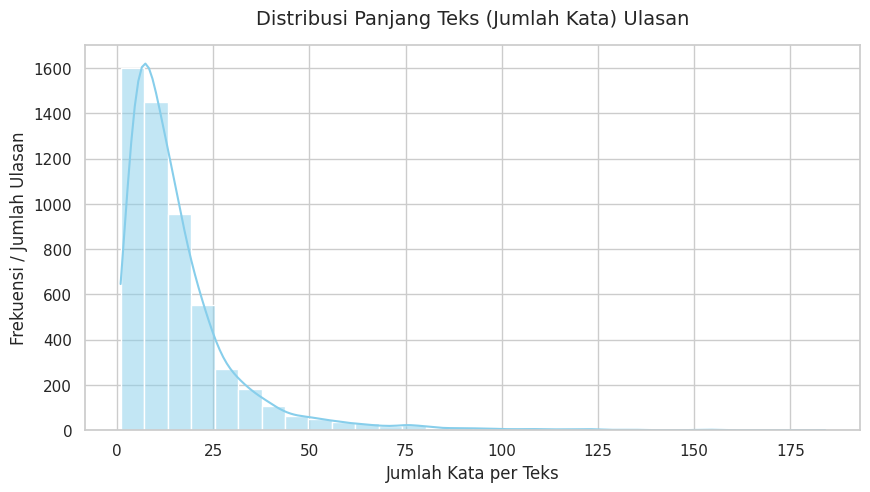


Jumlah data duplikat dalam dataset: 7


In [3]:
# 1. Analisis Distribusi Kelas Target (Emosi)
target_column = 'Emotion'

print("--- Distribusi Kelas Emosi ---")
print(df[target_column].value_counts())

# Visualisasi distribusi kelas menggunakan Countplot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_column, order=df[target_column].value_counts().index, palette='viridis')
plt.title('Distribusi Kelas Emosi pada Dataset PRDECT-ID', fontsize=14, pad=15)
plt.xlabel('Kelas Emosi', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 2. Analisis Karakteristik Teks (Menghitung Jumlah Kata per Baris)
text_column = 'Customer Review'

# Menghitung jumlah kata pada setiap baris teks
df['word_count'] = df[text_column].apply(lambda x: len(str(x).split()))

print("\n--- Statistik Deskriptif Panjang Teks (Jumlah Kata) ---")
print(df['word_count'].describe())

# Visualisasi distribusi panjang teks menggunakan Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Panjang Teks (Jumlah Kata) Ulasan', fontsize=14, pad=15)
plt.xlabel('Jumlah Kata per Teks', fontsize=12)
plt.ylabel('Frekuensi / Jumlah Ulasan', fontsize=12)
plt.show()

# 3. Memeriksa Duplikasi Data
duplicate_count = df.duplicated().sum()
print(f"\nJumlah data duplikat dalam dataset: {duplicate_count}")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# Import library untuk preprocessing dan machine learning
import string
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Memulai Data Preprocessing ---")

# Ambil dataset dari tahap sebelumnya
df_clean = df[['Customer Review', 'Emotion']].copy()
jml_awal = len(df_clean)

# 1. Menghapus atau Menangani Data Kosong (Missing Values)
# Meskipun di tahap EDA terlihat tidak ada missing value, kita pastikan
# secara eksplisit dengan fungsi dropna() agar data benar-benar aman.
df_clean = df_clean.dropna()
print(f"[1] Menangani Data Kosong: Selesai. (Jumlah data: {len(df_clean)})")

# 2. Menghapus Data Duplikat
# Menghapus 7 data duplikat yang kita temukan pada tahap EDA.
df_clean = df_clean.drop_duplicates()
print(f"[2] Menghapus Data Duplikat: Selesai. (Sisa data: {len(df_clean)} baris)")

# 3. Deteksi dan Penanganan Outlier (Disesuaikan untuk Teks)
# Untuk teks, "outlier" bisa berupa teks yang terlalu pendek (misal hanya 1 kata)
# karena kurang memberikan konteks emosi yang bermakna untuk model.
df_clean['word_count'] = df_clean['Customer Review'].apply(lambda x: len(str(x).split()))
df_clean = df_clean[df_clean['word_count'] > 1] # Membuang ulasan yang hanya 1 kata
df_clean = df_clean.drop(columns=['word_count'])
print(f"[3] Penanganan Outlier Teks: Membuang teks <= 1 kata. (Sisa data: {len(df_clean)} baris)")

# 4. Normalisasi atau Standarisasi Fitur (Disesuaikan untuk Teks/NLP)
# Pada teks, normalisasi dilakukan dengan Text Cleansing (lowercasing, hapus tanda baca, dll)
def clean_text(text):
    text = text.lower() # Case folding
    text = re.sub(r'\d+', '', text) # Menghapus angka
    text = text.translate(str.maketrans('', '', string.punctuation)) # Menghapus tanda baca
    text = text.strip() # Menghapus spasi di awal/akhir
    text = re.sub(r'\s+', ' ', text) # Menghapus spasi ganda
    return text

df_clean['cleaned_text'] = df_clean['Customer Review'].apply(clean_text)
print("[4] Normalisasi Fitur (Text Cleansing): Selesai.")

# 5. Encoding Data Kategorikal
# Mengubah kelas target 'Emotion' yang berupa teks menjadi angka (Label Encoding)
label_encoder = LabelEncoder()
df_clean['encoded_emotion'] = label_encoder.fit_transform(df_clean['Emotion'])
emotion_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"[5] Encoding Data Kategorikal: Selesai. \n    Mapping: {emotion_mapping}")

# Catatan: Tahap 6 "Binning" tidak dilakukan karena tidak relevan dengan
# karakteristik data tidak terstruktur berupa teks ulasan klasifikasi emosi.

print("\n--- Persiapan Pelatihan Model ---")

# Membagi data latih (80%) dan data uji (20%)
X = df_clean['cleaned_text']
y = df_clean['encoded_emotion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Split Data Selesai -> Data Latih: {len(X_train)} baris, Data Uji: {len(X_test)} baris")

# Ekstraksi Fitur Teks ke Numerik (TF-IDF Vectorization)
# Ini adalah tahap final agar teks benar-benar bisa dibaca oleh algoritma Machine Learning
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print(f"TF-IDF Vectorization Selesai -> Dimensi fitur latih: {X_train_tfidf.shape}")

# Menampilkan cuplikan hasil akhir
display(df_clean[['Customer Review', 'cleaned_text', 'encoded_emotion']].head())

--- Memulai Data Preprocessing ---
[1] Menangani Data Kosong: Selesai. (Jumlah data: 5400)
[2] Menghapus Data Duplikat: Selesai. (Sisa data: 5330 baris)
[3] Penanganan Outlier Teks: Membuang teks <= 1 kata. (Sisa data: 5277 baris)
[4] Normalisasi Fitur (Text Cleansing): Selesai.
[5] Encoding Data Kategorikal: Selesai. 
    Mapping: {'Anger': np.int64(0), 'Fear': np.int64(1), 'Happy': np.int64(2), 'Love': np.int64(3), 'Sadness': np.int64(4)}

--- Persiapan Pelatihan Model ---
Split Data Selesai -> Data Latih: 4221 baris, Data Uji: 1056 baris
TF-IDF Vectorization Selesai -> Dimensi fitur latih: (4221, 5000)


,Customer Review,cleaned_text,encoded_emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,alhamdulillah berfungsi dengan baik packaging ...,2
1,"barang bagus dan respon cepat, harga bersaing ...",barang bagus dan respon cepat harga bersaing d...,2
2,"barang bagus, berfungsi dengan baik, seler ram...",barang bagus berfungsi dengan baik seler ramah...,2
3,bagus sesuai harapan penjual nya juga ramah. t...,bagus sesuai harapan penjual nya juga ramah tr...,2
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",barang bagus pengemasan aman dapat berfungsi d...,2


In [8]:
# Import fungsi dari script
from automate_acep import run_pipeline

# Jalankan fungsinya
run_pipeline('PRDECT-ID Dataset.csv', 'processed_data.csv')

Otomatisasi selesai! Data tersimpan di processed_data.csv
